<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day12-discussion-2.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 12, Part 2 discussion — Does pLDDT know where the model is wrong?

pLDDT is AlphaFold's own estimate of per-residue accuracy. Test it:
superimpose AlphaFold DB models on crystal structures of the same
proteins, measure how far each residue actually is from its crystal
position, and compare with its pLDDT.

**Predict first:** will low-pLDDT residues be further from the crystal
structure? Will the relationship be sharp or loose?

In [1]:
import io, subprocess, sys, numpy as np, requests, matplotlib.pyplot as plt
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import three_to_index, index_to_one
def chain_residues(text, chain_id=None):
    model = PDBParser(QUIET=True).get_structure("x", io.StringIO(text))[0]
    chain = model[chain_id] if chain_id else next(iter(model))
    res = [r for r in chain if r.id[0] == " " and "CA" in r]
    return res, "".join(index_to_one(three_to_index(r.get_resname())) for r in res)
def pdb_text(pid):
    return requests.get(f"https://files.rcsb.org/download/{pid}.pdb", timeout=60).text

try:
    import tmtools
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tmtools"], check=True)
    import tmtools

pairs = [("P68871", "4HHB", "B", "beta-globin"), ("P02144", "3RGK", "A", "myoglobin"),
         ("P61626", "1LZ1", "A", "lysozyme"), ("P04637", "2OCJ", "A", "p53 DNA-binding domain")]
all_plddt, all_dev = [], []
for acc, pid, cid, name in pairs:
    meta = requests.get(f"https://alphafold.ebi.ac.uk/api/prediction/{acc}", timeout=60).json()[0]
    af, af_seq = chain_residues(requests.get(meta["pdbUrl"], timeout=60).text)
    xr, x_seq = chain_residues(pdb_text(pid), cid)
    A = np.array([r["CA"].coord for r in af]); B = np.array([r["CA"].coord for r in xr])
    t = tmtools.tm_align(A, B, af_seq, x_seq)
    A_sup = A @ t.u.T + t.t                                   # AlphaFold model moved onto the crystal
    ia = ib = 0; dev, pl = [], []
    for ca_, cb_ in zip(t.seqxA, t.seqyA):                    # walk the structural alignment
        if ca_ != "-" and cb_ != "-":
            dev.append(np.linalg.norm(A_sup[ia] - B[ib])); pl.append(af[ia]["CA"].get_bfactor())
        ia += ca_ != "-"; ib += cb_ != "-"
    dev, pl = np.array(dev), np.array(pl)
    all_plddt += list(pl); all_dev += list(dev)
    print(f"{name:24s} {len(dev):4d} aligned residues, TM-score {t.tm_norm_chain2:.3f}, "
          f"median deviation {np.median(dev):.2f} A, mean pLDDT {pl.mean():.1f}")
all_plddt, all_dev = np.array(all_plddt), np.array(all_dev)

beta-globin               146 aligned residues, TM-score 0.988, median deviation 0.42 A, mean pLDDT 97.4


myoglobin                 149 aligned residues, TM-score 0.989, median deviation 0.32 A, mean pLDDT 97.7


lysozyme                  130 aligned residues, TM-score 0.990, median deviation 0.27 A, mean pLDDT 98.4


p53 DNA-binding domain    194 aligned residues, TM-score 0.992, median deviation 0.33 A, mean pLDDT 95.5


pLDDT  50- 69:    2 residues, median deviation 0.73 A
pLDDT  70- 89:   11 residues, median deviation 0.81 A
pLDDT  90-100:  606 residues, median deviation 0.33 A


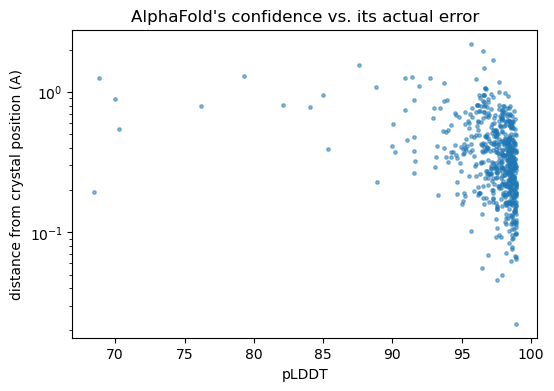

In [2]:
bins = [0, 50, 70, 90, 101]
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (all_plddt >= lo) & (all_plddt < hi)
    if m.any():
        print(f"pLDDT {lo:3d}-{hi - 1:3d}: {m.sum():4d} residues, median deviation {np.median(all_dev[m]):.2f} A")
plt.figure(figsize=(6, 4))
plt.scatter(all_plddt, all_dev, s=6, alpha=0.5)
plt.yscale("log"); plt.xlabel("pLDDT"); plt.ylabel("distance from crystal position (A)")
plt.title("AlphaFold's confidence vs. its actual error"); plt.show()

**Discuss:**

1. Is there a pLDDT threshold below which you would not trust individual
   residue positions? Where do the largest deviations sit (termini,
   loops)?
2. Most residues here have very high pLDDT. Why is it hard to test pLDDT
   properly on well-studied proteins like these, and what kind of
   proteins would you choose instead?
3. A crystal structure is one state, in a crystal. When the AlphaFold
   model and the crystal disagree, which one is "wrong"? (Lecture: check
   homologs, and the quality of both.)